Import required packages

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy import stats

Read consolidated, cleaned, and pre-processed data stored in `..\data` directory

In [25]:
birdsong_df = pd.read_csv("..\\data\\birdsong.csv")

### Snapshot of raw data

In [26]:
birdsong_df
birdsong_df.info()
birdsong_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 349430 entries, 0 to 349429
Data columns (total 14 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   common_name                         349430 non-null  str    
 1   date                                349430 non-null  str    
 2   bird_count                          349430 non-null  float64
 3   county                              349430 non-null  str    
 4   family                              349430 non-null  str    
 5   total_monthly_precipitation         349430 non-null  float64
 6   monthly_max_temp                    349430 non-null  float64
 7   monthly_min_temp                    349430 non-null  float64
 8   urban_population_level              349430 non-null  int64  
 9   county_total_population             349430 non-null  float64
 10  is_fire                             349430 non-null  int64  
 11  is_flood                            3

,common_name,date,bird_count,county,family,total_monthly_precipitation,monthly_max_temp,monthly_min_temp,urban_population_level,county_total_population,is_fire,is_flood,bird_count_adjusted_for_population,season
0,Band-tailed Pigeon,2021-01,1.0,Garfield,Pigeons and Doves,23.015789,1.412222,-10.458889,4,62178.480,0,0,0.000016,Winter
1,Pine Warbler,2021-01,1.0,Boulder,New World Warblers,9.873737,3.830000,-8.277778,5,333404.064,0,0,0.000003,Winter
2,White-winged Scoter,2021-01,1.0,Larimer,"Ducks, Geese, and Waterfowl",10.825893,1.854118,-10.457222,5,361938.528,0,0,0.000003,Winter
3,Brown Thrasher,2021-01,1.0,Boulder,Mockingbirds and Thrashers,9.873737,3.830000,-8.277778,5,333404.064,0,0,0.000003,Winter
4,Bonaparte's Gull,2021-01,2.0,Pueblo,"Gulls, Terns, and Skimmers",14.127778,8.566667,-8.400000,5,169507.296,0,0,0.000012,Winter


## Additional Data Transformations to Support Visualizations 

Grouped by County Monthly Aggregation (sorted descending by adjusted bird count)

In [27]:
# aggregate data by county, and date to get total bird count, county total population and average min and max temperatures per county, per month
birdsong_df_county_month = birdsong_df.groupby(['county', 'date']).agg({'bird_count': 'sum','county_total_population': 'mean', 'monthly_min_temp': 'mean', 'monthly_max_temp': 'mean', 'total_monthly_precipitation': 'mean', 'bird_count_adjusted_for_population': 'sum','is_fire': 'mean', 'is_flood': 'mean','urban_population_level': 'mean'}).reset_index()
print(birdsong_df_county_month.head())

  county     date  bird_count  county_total_population  monthly_min_temp  \
0  Adams  2021-01       410.0               523728.576         -6.441190   
1  Adams  2021-02       600.0               523728.576         -9.320278   
2  Adams  2021-03       105.0               523728.576         -3.354056   
3  Adams  2021-04       222.0               523728.576         -0.706306   
4  Adams  2021-05       253.0               523728.576          5.737639   

   monthly_max_temp  total_monthly_precipitation  \
0          8.038611                         1.50   
1          5.077778                         5.40   
2         11.264028                        45.70   
3         14.906611                        28.85   
4         19.938750                        68.40   

   bird_count_adjusted_for_population  is_fire  is_flood  \
0                            0.000783      0.0       0.0   
1                            0.001146      0.0       0.0   
2                            0.000200      0.0    

Grouped by County Annually (sorted descending by year and adjusted bird count)


In [28]:
# save date as year in new column called year
birdsong_df['year'] = pd.to_datetime(birdsong_df['date']).dt.to_period('Y')
# aggregate data by county, and year to get total bird count, county total population and average min and max temperatures per county, per month-year combination
birdsong_df_county_year= birdsong_df.groupby(['county', 'year']).agg({'bird_count': 'sum','county_total_population': 'mean', 'monthly_min_temp': 'mean', 'monthly_max_temp': 'mean', 'bird_count_adjusted_for_population': 'sum', 'is_fire': 'mean', 'is_flood': 'mean'}).reset_index()
# sort the dataframe by year and adjusted bird count in descending order to ensure the bars are in the correct order
birdsong_df_county_year_sorted = birdsong_df_county_year.sort_values(by=['year', 'bird_count_adjusted_for_population'], ascending=False)
birdsong_df_county_year_sorted.head(20)

,county,year,bird_count,county_total_population,monthly_min_temp,monthly_max_temp,bird_count_adjusted_for_population,is_fire,is_flood
164,Kit Carson,2025,53895.0,7375.052111,3.641933,19.975851,7.307745,0.0,0.0
149,Jackson,2025,4802.0,1435.049649,3.068174,18.525876,3.346226,0.0,0.0
49,Cheyenne,2025,4152.0,1819.047706,5.989339,23.780529,2.282513,0.0,0.0
189,Lincoln,2025,9781.0,5905.661172,3.564305,20.328770,1.656207,0.0,0.0
29,Bent,2025,5872.0,5879.645044,6.811904,24.768598,0.998700,0.0,0.0
59,Conejos,2025,7110.0,7764.253393,-3.796379,13.073621,0.915735,0.0,0.0
159,Kiowa,2025,1254.0,1504.772873,5.512301,22.062235,0.833348,0.0,0.0
269,Rio Grande,2025,8830.0,12008.004276,-2.379368,14.346702,0.735343,0.0,0.0
224,Morgan,2025,14521.0,30294.220685,6.720703,25.466324,0.479332,0.0,0.0
234,Ouray,2025,2348.0,5072.104415,4.956041,22.871598,0.462924,0.0,0.0


Grouped by County All Years (sorted descending by adjusted bird count)

In [29]:
# aggregate data by county to get total bird count, county total population and average min  and max temperatures per county
birdsong_df_county = birdsong_df.groupby(['county']).agg({'bird_count': 'sum',
'county_total_population': 'mean', 'monthly_min_temp': 'min', 'monthly_max_temp': 'max', 'total_monthly_precipitation': 'mean', 'urban_population_level': 'mean','bird_count_adjusted_for_population': 'sum', 'is_fire': 'mean', 'is_flood': 'mean'}).reset_index()
print(birdsong_df_county.head(20))
# sort the dataframe by count_per_capita in descending order to ensure the bars are in the correct order
birdsong_df_county_sorted = birdsong_df_county.sort_values(by='bird_count_adjusted_for_population', ascending=False)
print(birdsong_df_county_sorted.head(20))

         county  bird_count  county_total_population  monthly_min_temp  \
0         Adams     30690.0            531126.403615        -11.910694   
1       Alamosa      8696.0             16747.413034        -16.210000   
2      Arapahoe    167403.0            672554.238962        -10.313333   
3     Archuleta      5672.0             13663.329380        -13.655000   
4          Baca     39636.0              3588.090902        -10.830000   
5          Bent     66206.0              5775.675887        -12.290000   
6       Boulder    260988.0            338416.195310        -12.433333   
7    Broomfield     27914.0             76238.262398        -12.350000   
8       Chaffee     22185.0             19954.343614        -15.246667   
9      Cheyenne      6116.0              1796.085375        -12.746667   
10  Clear Creek      7672.0              9599.757254        -16.188000   
11      Conejos     29714.0              7607.713845        -14.352500   
12     Costilla      5334.0           

Grouped by Family Monthly

In [30]:
# save date as year in new column called year
birdsong_df['month-year'] = pd.to_datetime(birdsong_df['date']).dt.to_period('M')
# aggregate data by family, and year to get total bird count, family total population and average min and max temperatures per family, per month-year combination
birdsong_df_family_month = birdsong_df.groupby(['family', 'month-year']).agg({'bird_count': 'sum',
'county_total_population': 'mean', 'monthly_min_temp': 'mean', 'monthly_max_temp': 'mean', 'total_monthly_precipitation': 
'mean', 'bird_count_adjusted_for_population': 'sum','is_fire': 'mean', 'is_flood': 'mean','urban_population_level': 
'mean'}).reset_index()
# sort the dataframe by year and adjusted bird count in descending order to ensure the bars are in the correct order
birdsong_df_family_month_sorted = birdsong_df_family_month.sort_values(by=['month-year', 
'bird_count_adjusted_for_population'], ascending=False)
birdsong_df_family_month_sorted.head(20)
birdsong_df_family_month.info()

<class 'pandas.DataFrame'>
RangeIndex: 3178 entries, 0 to 3177
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype    
---  ------                              --------------  -----    
 0   family                              3178 non-null   str      
 1   month-year                          3178 non-null   period[M]
 2   bird_count                          3178 non-null   float64  
 3   county_total_population             3178 non-null   float64  
 4   monthly_min_temp                    3178 non-null   float64  
 5   monthly_max_temp                    3178 non-null   float64  
 6   total_monthly_precipitation         3178 non-null   float64  
 7   bird_count_adjusted_for_population  3178 non-null   float64  
 8   is_fire                             3178 non-null   float64  
 9   is_flood                            3178 non-null   float64  
 10  urban_population_level              3178 non-null   float64  
dtypes: float64(9), period[M](1),

## Visualizations

#### County Min and Max Temp vs Adjusted Bird Counts



C:\Users\kenny\AppData\Local\Temp\ipykernel_544\1862923930.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=8)


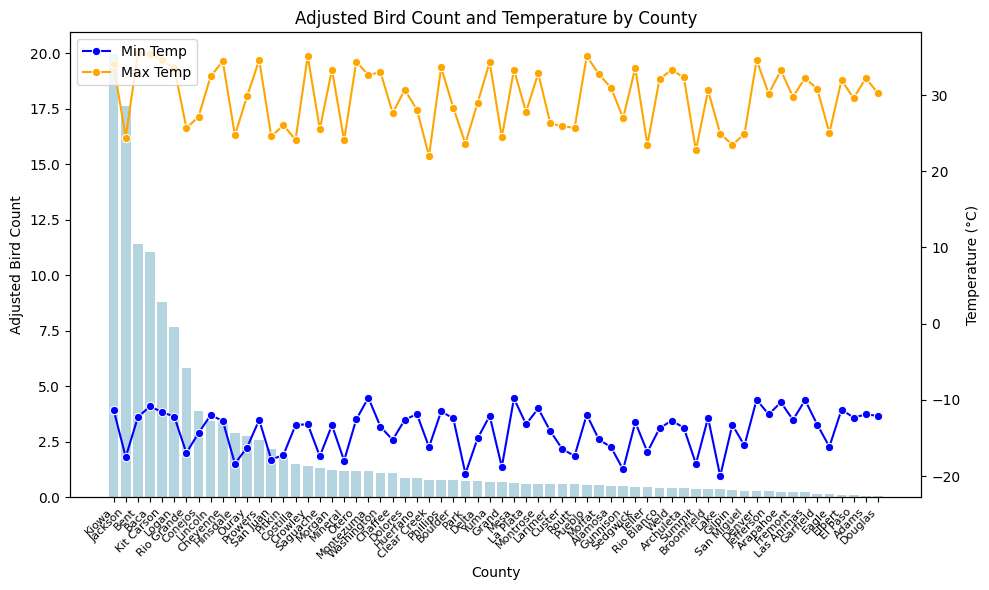

In [31]:
# Line graph with 2 lines, one for min temp per county and one with max temp per county overlay ontop of bar graph of bird counts per capita per county in descending count order. 

# Create figure and axis objects
fig, ax1 = plt.subplots(figsize=(10, 6))
# Plot bar graph of bird counts per capita per county in descending order by count
sns.barplot(x='county', y='bird_count_adjusted_for_population', data=birdsong_df_county.sort_values(by='bird_count_adjusted_for_population', ascending=False), ax=ax1, color='lightblue', errorbar=None)
ax1.set_xlabel('County')
ax1.set_ylabel('Adjusted Bird Count')
ax1.tick_params(axis='y')
# Create second y-axis for temperature
ax2 = ax1.twinx()
# Plot line graph of min and max temperatures per county
sns.lineplot(x='county', y='monthly_min_temp', data=birdsong_df_county, ax=ax2, color='blue', marker='o', label='Min Temp')
sns.lineplot(x='county', y='monthly_max_temp', data=birdsong_df_county, ax=ax2, color='orange', marker='o', label='Max Temp')
ax2.set_ylabel('Temperature (°C)')     
ax2.tick_params(axis='y')
# Add title and legend
plt.title('Adjusted Bird Count and Temperature by County')
ax2.legend(loc='upper left')
# Reduce the size of the x-axis labels
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=8)
# Show the plot
plt.tight_layout()
# Save the plot as a PNG file
plt.savefig('..\\output\\visualizations\\adjusted_bird_count_and_temperature_by_county.png', dpi=300)
plt.show()

### Plots of Relations between Variables

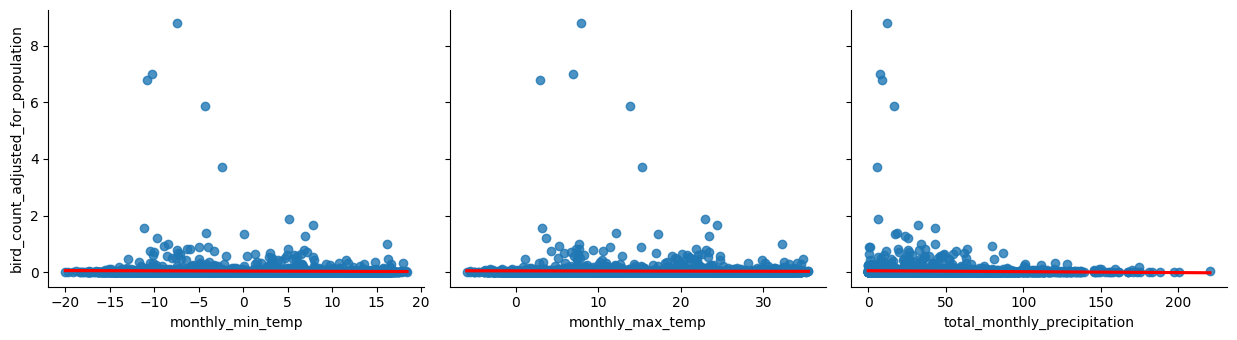

In [32]:
# Create pairplot with regression lines
p = sns.pairplot(birdsong_df_county_month, x_vars=['monthly_min_temp', 'monthly_max_temp', 'total_monthly_precipitation'], y_vars='bird_count_adjusted_for_population', kind='reg', height=3.5, aspect=1.2, plot_kws={'line_kws':{'color':'red'}})   
p.fig.subplots_adjust(top=0.5)  # Adjust the top spacing to make room for the title  
plt.tight_layout()
# Save the plot as a PNG file
plt.savefig('..\\output\\visualizations\\bird_count_weather_relationships.png', dpi=300)
plt.show()


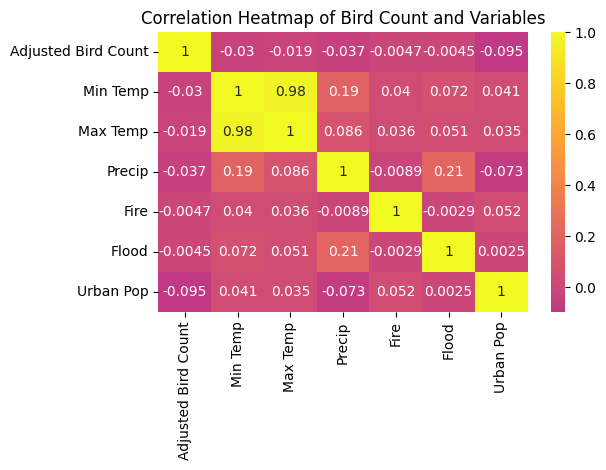

In [33]:
# Create a correlation matrix plot for the relevant variables and rename the columns for better readability in the heatmap
corr_matrix = birdsong_df_county_month[['bird_count_adjusted_for_population', 'monthly_min_temp', 'monthly_max_temp', 'total_monthly_precipitation' , 'is_fire', 'is_flood', 'urban_population_level']].corr()
corr_matrix.columns = ['Adjusted Bird Count', 'Min Temp', 'Max Temp', 'Precip', 'Fire', 'Flood', 'Urban Pop']
corr_matrix.index = ['Adjusted Bird Count', 'Min Temp', 'Max Temp', 'Precip', 'Fire', 'Flood', 'Urban Pop']
sns.heatmap(corr_matrix, annot=True, cmap='plasma', center=0)
plt.title('Correlation Heatmap of Bird Count and Variables')
plt.tight_layout()
# Save the plot as a PNG file
plt.savefig('..\\output\\visualizations\\correlation_heatmap_bird_count_variables.png', dpi=300)
plt.show()


### Plot of Frequency of Wildfires by County

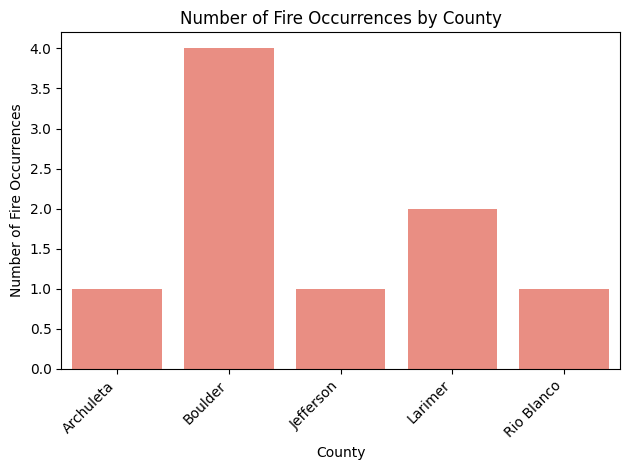

In [34]:
fire_counts = birdsong_df[birdsong_df['is_fire'] == 1].groupby('county')['date'].nunique().reset_index()
fire_counts.columns = ['county', 'fire_occurrences']
sns.barplot(x='county', y='fire_occurrences', data=fire_counts, color='salmon', errorbar=None)
plt.xlabel('County')
plt.ylabel('Number of Fire Occurrences')
plt.title('Number of Fire Occurrences by County')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# Save the plot as a PNG file
plt.savefig('..\\output\\visualizations\\fire_occurrences_by_county.png', dpi=300)
plt.show()

### Plots of Bird Counts against Urban Population Level

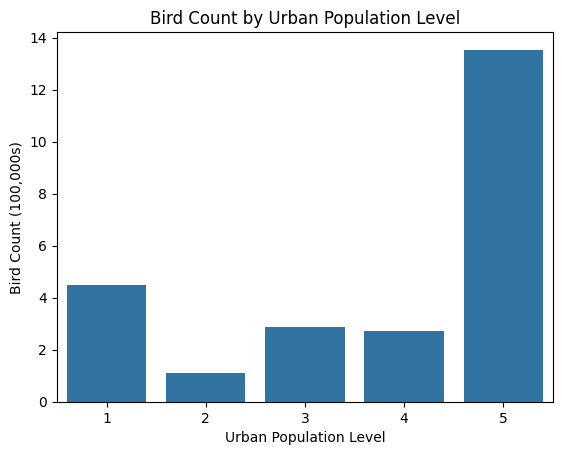

In [35]:
# Plot relationship of bird count against urban population level
birdsong_df_grouped = birdsong_df.groupby('urban_population_level')['bird_count'].sum().reset_index()
sns.barplot(x='urban_population_level', y='bird_count', data=birdsong_df_grouped, errorbar=None, units='bird_count', estimator=lambda x: x.sum()/100000)
plt.xlabel('Urban Population Level')
plt.ylabel('Bird Count (100,000s)')
plt.title('Bird Count by Urban Population Level')
# Save the plot as a PNG file
plt.savefig('..\\output\\visualizations\\bird_count_by_urban_population_level.png', dpi=300)
plt.show()

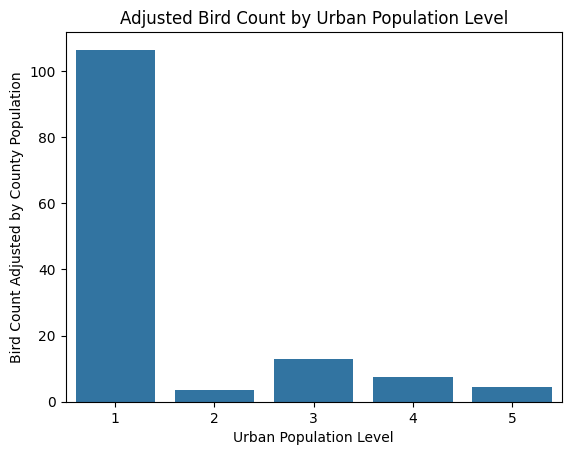

In [36]:
# Plot relationship of bird count adjusted by county population against urban population level
birdsong_df_grouped = birdsong_df.groupby('urban_population_level')['bird_count_adjusted_for_population'].sum().reset_index()
sns.barplot(x='urban_population_level', y='bird_count_adjusted_for_population', data=birdsong_df_grouped, errorbar=None, units='bird_count_adjusted_for_population', estimator=lambda x: x.sum())
plt.xlabel('Urban Population Level')
plt.ylabel('Bird Count Adjusted by County Population')
plt.title('Adjusted Bird Count by Urban Population Level')
# Save the plot as a PNG file
plt.savefig('..\\output\\visualizations\\adjusted_bird_count_by_urban_population_level.png', dpi=300)
plt.show()

### Plots of Bird Count over Time

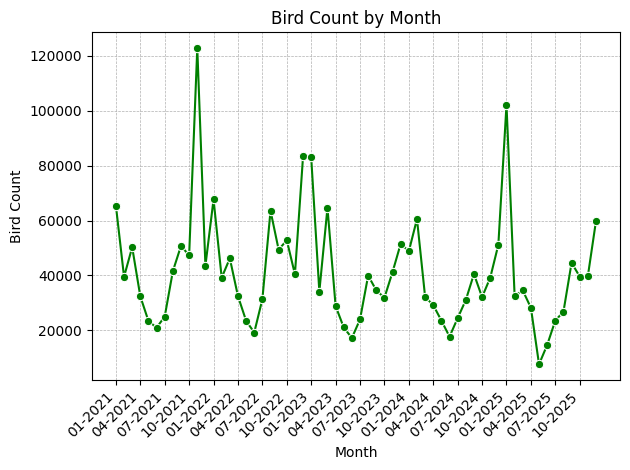

In [37]:
# Convert date column to datetime format
birdsong_df['date'] = pd.to_datetime(birdsong_df['date'])
birdsong_df_recent_monthly = birdsong_df.groupby('date')['bird_count'].sum().reset_index()
birdsong_df_recent_monthly['month_year'] = birdsong_df_recent_monthly['date'].dt.strftime('%m-%Y')
sns.lineplot(x='month_year', y='bird_count', data=birdsong_df_recent_monthly, marker='o', linestyle='-', color='green')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)  
plt.xlabel('Month')
plt.ylabel('Bird Count')
plt.title('Bird Count by Month')
# only show every 3rd month-year label on the x-axis for better readability
plt.xticks(ticks=range(0, len(birdsong_df_recent_monthly), 3), labels=birdsong_df_recent_monthly['month_year'][::3], rotation=45, ha='right')
# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# Save the plot as a PNG file
plt.savefig('..\\output\\visualizations\\bird_count_by_month.png', dpi=300)
plt.show()

### Plots of Bird Species by Count

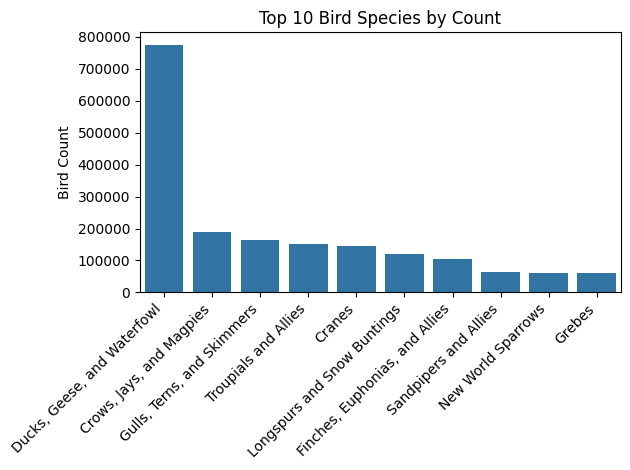

In [38]:
# Plot top 10 bird species by count
top_species = birdsong_df.groupby('family')['bird_count'].sum().reset_index().sort_values(by='bird_count', ascending=False).head(10)
top10 = sns.barplot(x='family', y='bird_count', data=top_species,  errorbar=None)
top10.set(xlabel=None, ylabel='Bird Count', title='Top 10 Bird Species by Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# Save the plot as a PNG file
plt.savefig('..\\output\\visualizations\\top_10_bird_species_by_count.png', dpi=300)
plt.show()

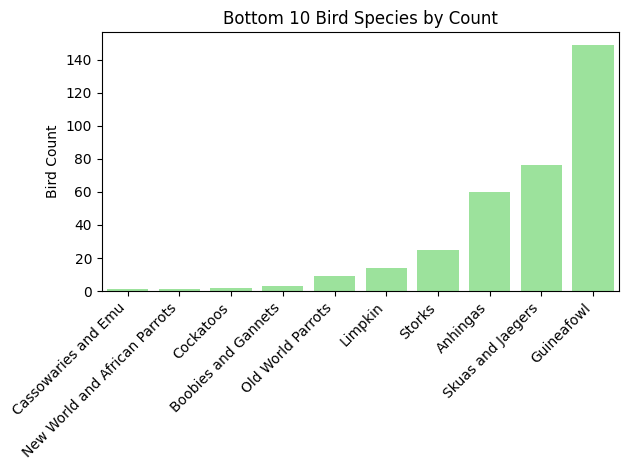

In [39]:
# Plot bottom 10 bird species by count
bottom_species = birdsong_df.groupby('family')['bird_count'].sum().reset_index().sort_values(by='bird_count', ascending=True).head(10)
bottom10 = sns.barplot(x='family', y='bird_count', data=bottom_species, color='lightgreen', errorbar=None)
bottom10.set(xlabel=None, ylabel='Bird Count', title='Bottom 10 Bird Species by Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# Save the plot as a PNG file
plt.savefig('..\\output\\visualizations\\bottom_10_bird_species_by_count.png', dpi=300)
plt.show()

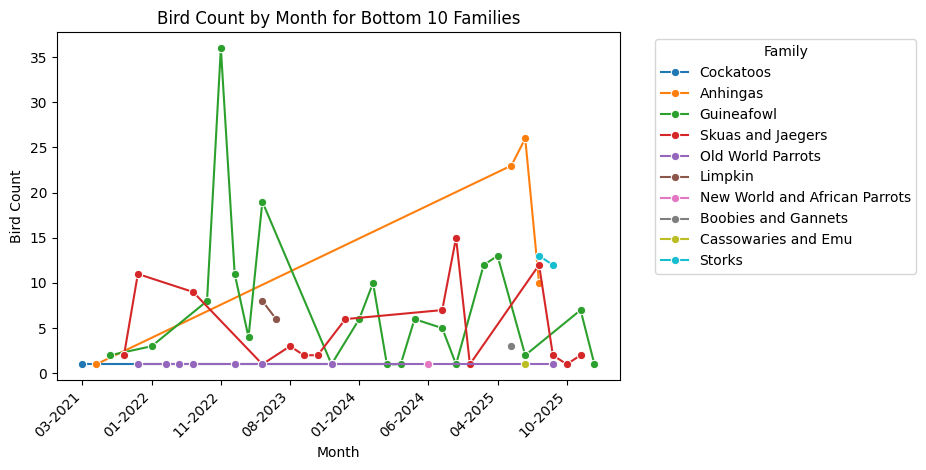

In [40]:
#  Plot bottom 10 bird families by count over time

birdsong_df_family_month_sorted_bottom = birdsong_df_family_month_sorted[birdsong_df_family_month_sorted['family'].isin(bottom_species['family'])]
# sort the dataframe by month-year and bird count in descending order to ensure the lines are in the correct order
birdsong_df_family_month_sorted_bottom = birdsong_df_family_month_sorted_bottom.sort_values(by=['month-year', 'bird_count'], ascending=[True, False])
birdsong_df_family_month_sorted_bottom = birdsong_df_family_month_sorted_bottom.sort_values(by=['month-year', 'bird_count'], ascending=[True, False])
birdsong_df_family_month_sorted_bottom['month-year'] = birdsong_df_family_month_sorted_bottom['month-year'].astype(str)
birdsong_df_family_month_sorted_bottom['month-year'] = pd.to_datetime(birdsong_df_family_month_sorted_bottom['month-year']).dt.strftime('%m-%Y')
sns.lineplot(x='month-year', y='bird_count', hue='family', data=birdsong_df_family_month_sorted_bottom, marker='o', linestyle='-')
plt.xlabel('Month')
plt.ylabel('Bird Count')
plt.title('Bird Count by Month for Bottom 10 Families')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(title='Family', bbox_to_anchor=(1.05, 1), loc='upper left')
# only show every 3rd month-year label on the x-axis for better readability
plt.xticks(ticks=range(0, len(birdsong_df_family_month_sorted_bottom['month-year'].unique()), 5), labels=birdsong_df_family_month_sorted_bottom['month-year'].unique()[::5], rotation=45, ha='right')
# Save the plot and legend as a PNG file
plt.savefig('..\\output\\visualizations\\bird_count_by_month_for_bottom_10_families.png', dpi=300, bbox_inches='tight')
plt.show()


### Plot of Adjusted Bird Count grouped by Species Family againt Monthly Max Temperature

The goal is to determine if there are noticeable patterns among bird species families in terms of how their counts vary with the monthly max temperature.

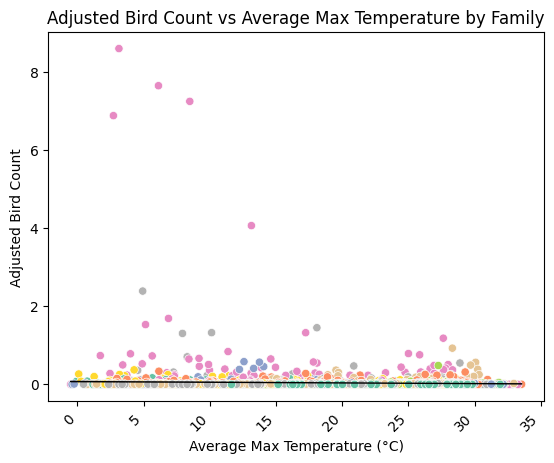

In [41]:
sns.scatterplot(x='monthly_max_temp', y='bird_count_adjusted_for_population', hue='family', data=birdsong_df_family_month, palette='Set2', legend=False)
sns.regplot(x='monthly_max_temp', y='bird_count_adjusted_for_population', data=birdsong_df_family_month, scatter=False, color='black', line_kws={'linewidth':1})
plt.xlabel('Average Max Temperature (°C)')          
plt.ylabel('Adjusted Bird Count')
plt.title('Adjusted Bird Count vs Average Max Temperature by Family')
plt.xticks(rotation=45, ha='right')
# Save the plot as a PNG file
plt.savefig('..\\output\\visualizations\\bird_count_vs_avg_max_temp_by_family.png', dpi=300)
plt.show()

### Plots of Weather Data

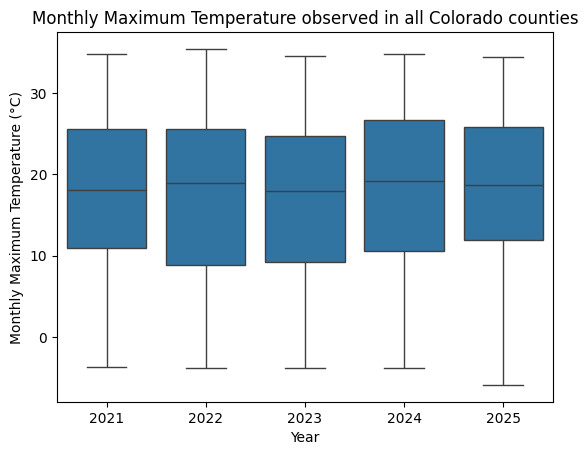

In [ ]:
# Plot of maximum temperatures per month observed in all Colorado counties, by year
birdsong_df["year"] = birdsong_df["date"].dt.to_period("Y")
ax = sns.boxplot(data = birdsong_df, x = "year", y = "monthly_max_temp")
ax.set_title('Monthly Maximum Temperature observed in all Colorado counties')
ax.set_ylabel('Monthly Maximum Temperature (°C)')
ax.set_xlabel('Year')
plt.show()

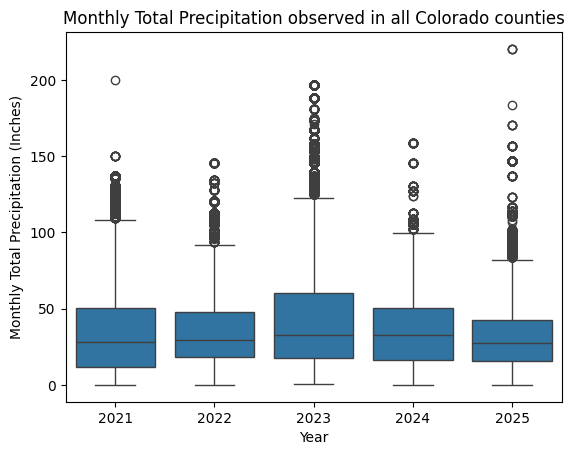

In [ ]:
# Plot of total precipitation per month observed in all Colorado counties, by year
ax = sns.boxplot(data = birdsong_df, x = "year", y = "total_monthly_precipitation")
ax.set_title('Monthly Total Precipitation observed in all Colorado counties')
ax.set_ylabel("Monthly Total Precipitation (Inches)")
ax.set_xlabel('Year')
plt.show()

### Distributions of bird counts throughout the year from 2021 to 2025

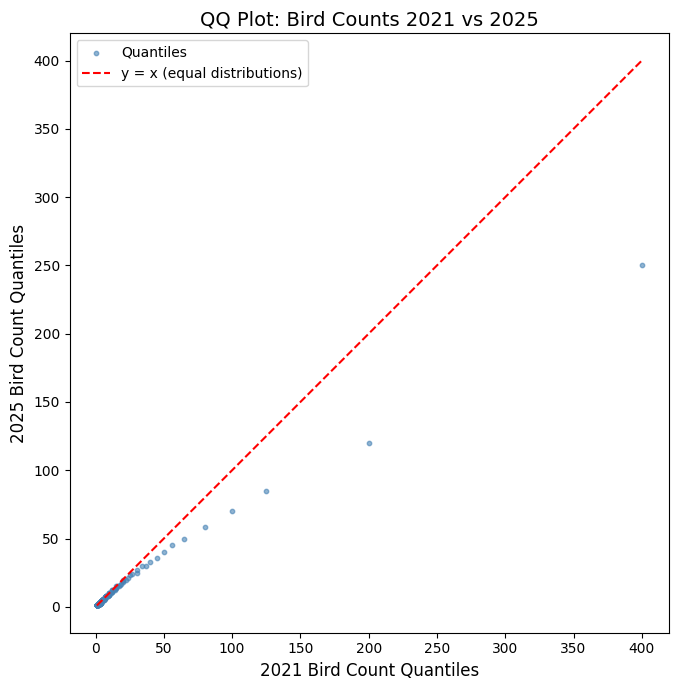

In [44]:
counts_2021 = birdsong_df[birdsong_df["date"].dt.year == 2021]["bird_count"]
counts_2025 = birdsong_df[birdsong_df["date"].dt.year == 2025]["bird_count"]

# Compute quantiles over a common probability grid
percentiles = np.linspace(0, 100, 500)
q_2021 = np.percentile(counts_2021, percentiles)
q_2025 = np.percentile(counts_2025, percentiles)
# Remove the largest value in q_2021 and q_2025 for the q-q plot as it is an outlier that skews the plot
q_2021 = q_2021[:-1]
q_2025 = q_2025[:-1]
# Plot
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(q_2021, q_2025, s=10, alpha=0.6, color="steelblue", label="Quantiles")

# Reference line (y = x) spanning the full data range
min_val = min(q_2021.min(), q_2025.min())
max_val = max(q_2021.max(), q_2025.max())
ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5, label="y = x (equal distributions)")

ax.set_xlabel("2021 Bird Count Quantiles", fontsize=12)
ax.set_ylabel("2025 Bird Count Quantiles", fontsize=12)
ax.set_title("QQ Plot: Bird Counts 2021 vs 2025", fontsize=14)
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("..\\output\\visualizations\\qq_plot_birds.png", dpi=150)
plt.show()